# 02 · Training the models

We train three models on the dataset:

* a **classifier** predicting which controller will win, and
* two **regressors** predicting the winner's settling time and overshoot.

Random forests are the default here — they handle the mixed-scale features with no scaling, tolerate the heavy tail in settling time, and expose feature importances.

In [1]:
# Make the controlbench package importable when running from notebooks/
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from controlbench.ml import load_dataset, generate_dataset, save_dataset, train_models, save_models
from controlbench.ml.features import FEATURE_NAMES

### Load the dataset
We load `data/dataset.csv` if it exists (built by `scripts/build_ml.py`); otherwise we generate it here so the notebook is self-contained.

In [3]:
csv = Path('..') / 'data' / 'dataset.csv'
if csv.exists():
    df = load_dataset(csv)
    print('loaded', len(df), 'rows from', csv)
else:
    print('dataset not found - generating 2000 rows (~3 min)...')
    df = generate_dataset(2000, seed=42)
    save_dataset(df, csv)
df.head()

loaded 2000 rows from ..\data\dataset.csv


,order,damping_ratio,natural_frequency,dc_gain,den_a1,den_a2,den_a3,num_s,num_1,best_controller,best_settling_time,best_overshoot,best_score
0,1.0,1.0,2.306617,0.775117,2.306617,0.000000,0.000000,0.000000,1.787897,P,0.714209,0.000000,0.924092
1,3.0,1.0,0.652051,0.249881,8.478631,20.413588,9.983073,1.056197,2.494582,P,2.406962,0.000000,0.933023
2,1.0,1.0,3.290553,0.527006,3.290553,0.000000,0.000000,0.000000,1.734142,P,0.500648,0.000000,0.928430
3,3.0,1.0,0.506323,1.527580,2.130385,2.693784,0.947575,0.000000,1.447497,PID,9.074830,30.740602,0.757605
4,1.0,1.0,1.901725,1.028565,1.901725,0.000000,0.000000,0.000000,1.956047,P,0.866270,0.000000,0.920180


### Train and score on a held-out test set

In [4]:
models = train_models(df, seed=42)
scores = models['scores']
for k, v in scores.items():
    print(f'{k:22} {v:.4f}' if isinstance(v, float) else f'{k:22} {v}')

controller_accuracy    0.9125
settling_r2            0.5602
settling_mae           2.5873
overshoot_r2           0.4494
overshoot_mae          6.1026
n_train                1600
n_test                 400


* **controller_accuracy** — how often the classifier names the true winning controller.
* **settling_r2 / overshoot_r2** — variance explained by the regressors (1.0 is perfect).
* **_mae** — average absolute error, in seconds and in percent respectively.

### Which features matter?

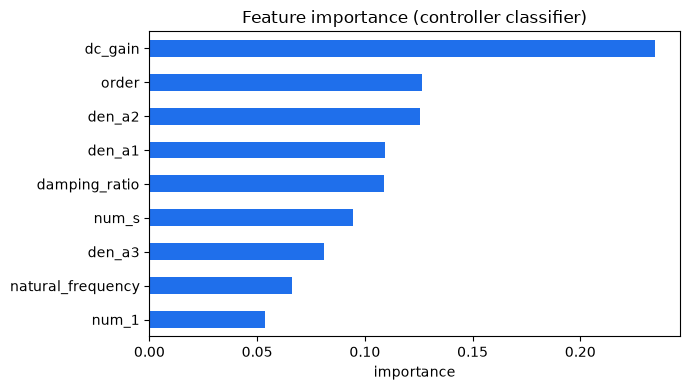

In [5]:
imp = pd.Series(models['classifier'].feature_importances_, index=FEATURE_NAMES)
imp = imp.sort_values()
imp.plot.barh(figsize=(7, 4), color='#1f6feb')
plt.title('Feature importance (controller classifier)'); plt.xlabel('importance')
plt.tight_layout(); plt.show()

### Confusion matrix on the held-out rows

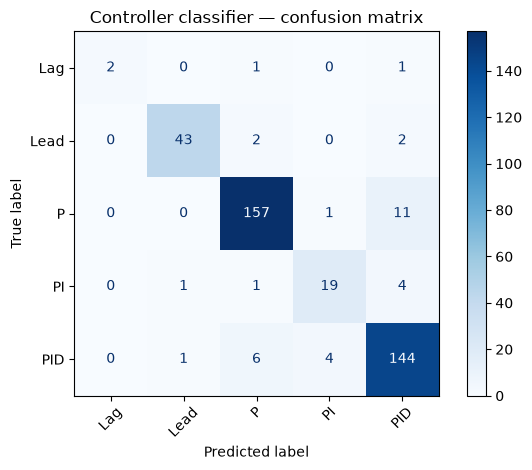

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
y = df['best_controller']
strat = y if y.value_counts().min() >= 2 else None
idx_tr, idx_te = train_test_split(df.index, test_size=0.2, random_state=42, stratify=strat)
ConfusionMatrixDisplay.from_predictions(
    y.loc[idx_te], models['classifier'].predict(df[FEATURE_NAMES].loc[idx_te]),
    xticks_rotation=45, cmap='Blues')
plt.title('Controller classifier — confusion matrix'); plt.tight_layout(); plt.show()

### Save the trained models

In [7]:
save_models(models, Path('..') / 'models')
print('saved models to ../models')

saved models to ../models
